# 01 — Exploratory Data Analysis: Policyholder Lapsation

**Goal:** understand the data before modelling. Every section ends with a finding that feeds a modelling decision.

**Dataset:** 100,000 synthetic life insurance policyholders, parameterised from APRA 2024 Life Insurance Quarterly Statistics.

**Target:** `lapsed` (1 = policyholder cancelled cover before natural expiry).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

df = pd.read_parquet("../data/policyholders.parquet")

Matplotlib is building the font cache; this may take a moment.


## 1. Data inspection

In [2]:
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 100,000   Columns: 11


,policy_id,age_at_inception,gender,smoker_status,product_type,sum_insured,annual_premium,premium_loading_pct,policy_tenure_months,prior_claim_count,lapsed
0,POL0000001,44,M,N,TPD,947000,1973.81,27.4,27,0.0,0
1,POL0000002,37,F,N,Death,120000,166.88,24.7,27,0.0,1
2,POL0000003,46,M,N,TPD,233000,679.07,0.0,120,0.0,1
3,POL0000004,56,F,N,TPD,295000,775.56,0.0,44,0.0,0
4,POL0000005,36,M,N,IP,89000,589.60,0.0,80,1.0,0


In [3]:
df.dtypes

policy_id                   str
age_at_inception          int64
gender                      str
smoker_status               str
product_type                str
sum_insured               int64
annual_premium          float64
premium_loading_pct     float64
policy_tenure_months      int64
prior_claim_count       float64
lapsed                    int64
dtype: object

In [4]:
df.describe().round(2)

,age_at_inception,sum_insured,annual_premium,premium_loading_pct,policy_tenure_months,prior_claim_count,lapsed
count,100000.00,100000.00,100000.00,95949.00,100000.00,98430.00,100000.00
mean,38.39,350597.86,803.20,6.17,41.97,0.12,0.21
std,11.03,408085.45,899.54,13.16,41.94,0.35,0.40
min,18.00,50000.00,34.35,0.00,1.00,0.00,0.00
25%,31.00,100000.00,317.28,0.00,12.00,0.00,0.00
50%,38.00,222500.00,527.48,0.00,29.00,0.00,0.00
75%,46.00,442000.00,955.23,0.00,58.00,0.00,0.00
max,75.00,5000000.00,22617.37,50.00,300.00,4.00,1.00


## 2. Missing data

Before filling anything, look at *how much* is missing and *where*.

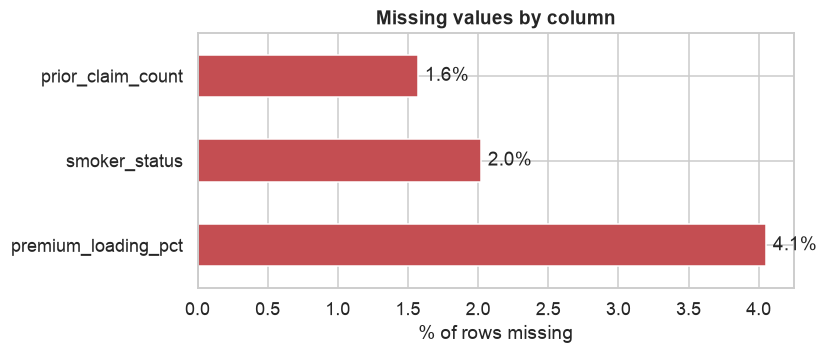

In [5]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(7, 3))
missing.plot.barh(ax=ax, color="#C44E52")
ax.set_xlabel("% of rows missing")
ax.set_title("Missing values by column")
for i, v in enumerate(missing):
    ax.text(v + 0.05, i, f"{v:.1f}%", va="center")
save(fig, "01_missing_values")
plt.show()

In [6]:
# Does missingness relate to the target? If yes, the missingness itself carries signal.
for col in missing.index:
    rate_missing = df.loc[df[col].isna(), "lapsed"].mean()
    rate_present = df.loc[df[col].notna(), "lapsed"].mean()
    print(f"{col:22s} lapse rate when missing: {rate_missing:.3f}  | when present: {rate_present:.3f}")

premium_loading_pct    lapse rate when missing: 0.208  | when present: 0.206
smoker_status          lapse rate when missing: 0.212  | when present: 0.206
prior_claim_count      lapse rate when missing: 0.197  | when present: 0.206


**Finding:** missingness is low (under 5% per column) and the lapse rate is similar whether values are missing or present, so the data looks missing at random.

**Decision:** median imputation for `premium_loading_pct` and `prior_claim_count`, and an explicit `"Unknown"` category for `smoker_status` (so the model can learn from it if it matters).

## 3. Univariate distributions

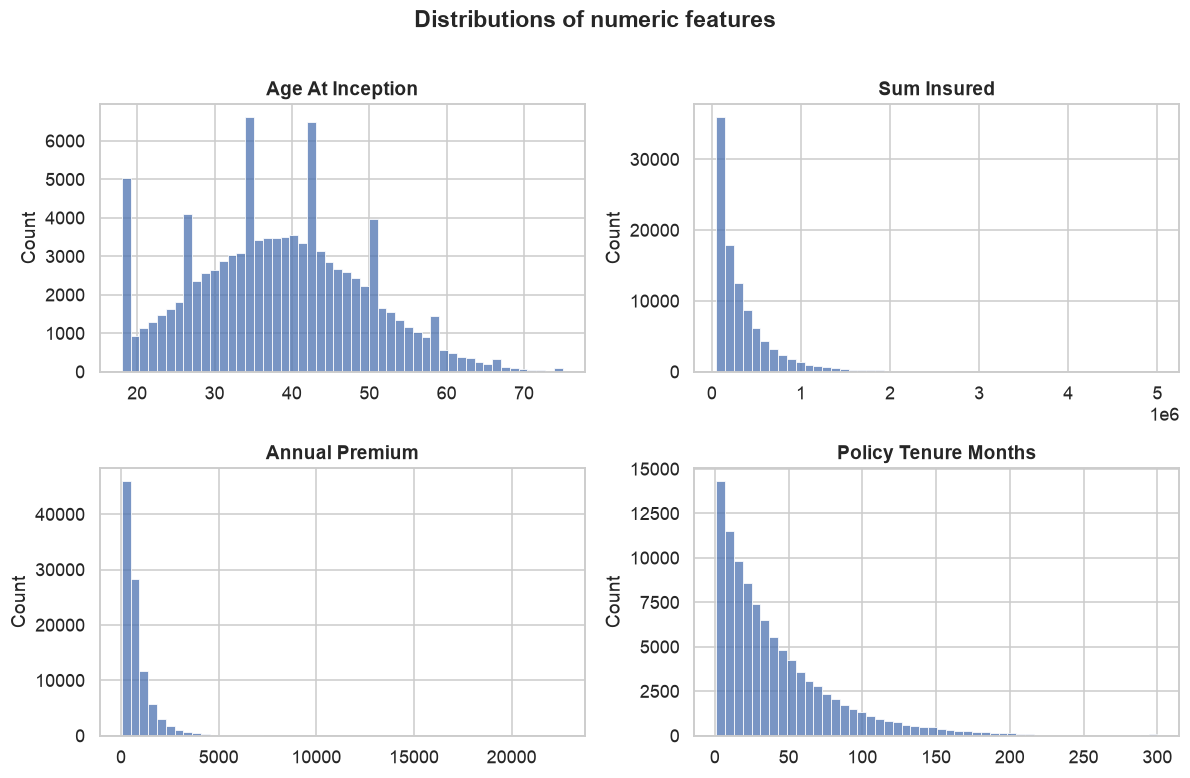

Skewness:
age_at_inception        0.18
sum_insured             3.59
annual_premium          4.52
policy_tenure_months    1.94
dtype: float64


In [7]:
num_cols = ["age_at_inception", "sum_insured", "annual_premium", "policy_tenure_months"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=50, ax=ax, color="#4C72B0")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
fig.suptitle("Distributions of numeric features", fontweight="bold", y=1.01)
fig.tight_layout()
save(fig, "02_numeric_distributions")
plt.show()

print("Skewness:")
print(df[num_cols].skew().round(2))

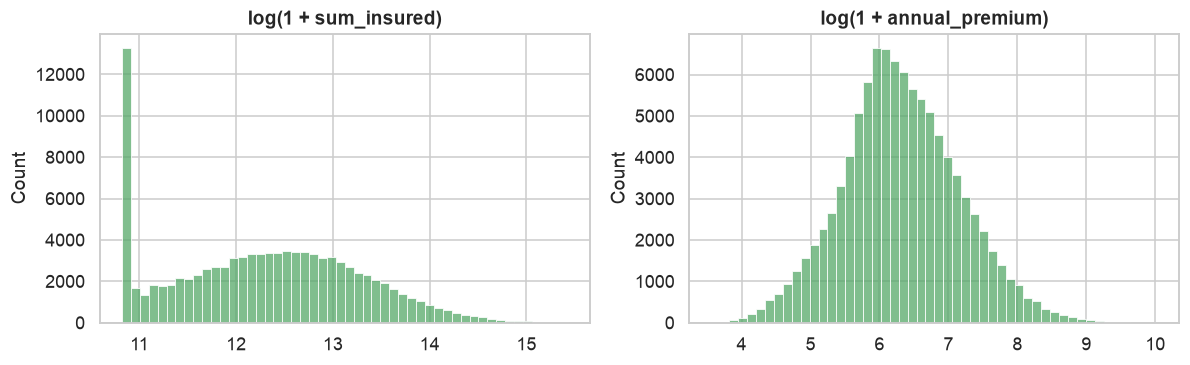

In [8]:
# Right-skewed money columns look much more normal on a log scale
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col in zip(axes, ["sum_insured", "annual_premium"]):
    sns.histplot(np.log1p(df[col]), bins=50, ax=ax, color="#55A868")
    ax.set_title(f"log(1 + {col})")
    ax.set_xlabel("")
fig.tight_layout()
save(fig, "03_log_transformed")
plt.show()

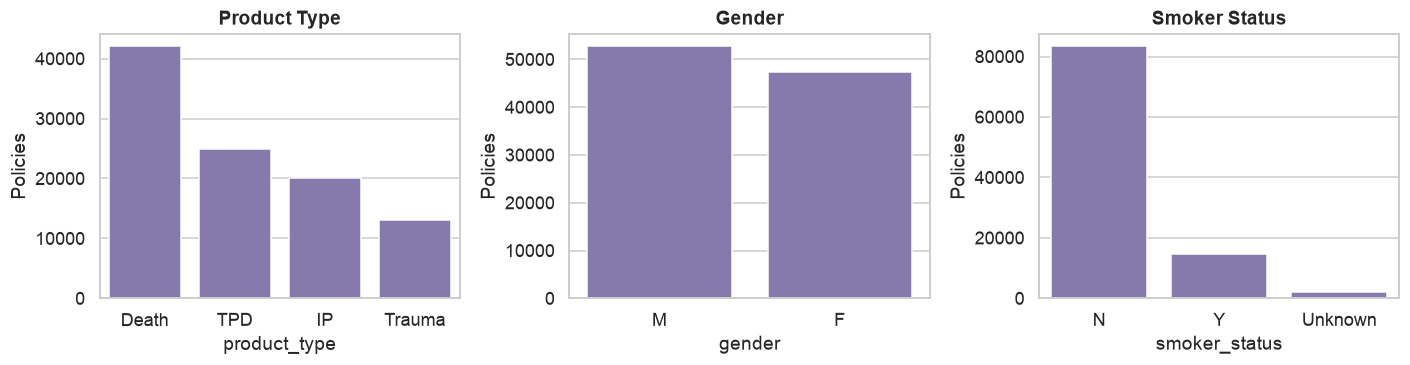

In [9]:
cat_cols = ["product_type", "gender", "smoker_status"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, cat_cols):
    counts = df[col].fillna("Unknown").value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color="#8172B3")
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("Policies")
fig.tight_layout()
save(fig, "04_categorical_counts")
plt.show()

**Finding:** `sum_insured` and `annual_premium` are heavily right-skewed (log-normal), which is typical for money values. Age is roughly normal. Tenure is skewed toward recent policies.

**Decision:** log-transform the two money columns for logistic regression. Tree models (XGBoost) don't need it, because splits don't care about scale.

## 4. The target: who lapses?

Overall lapse rate: 20.59%
A model that always predicts 'no lapse' would score 79.4% accuracy while catching zero lapses.


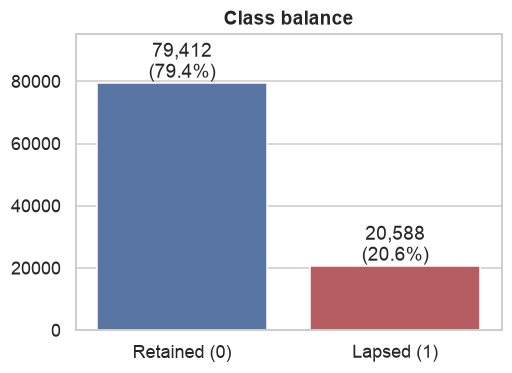

In [10]:
rate = df["lapsed"].mean()
print(f"Overall lapse rate: {rate:.2%}")
print(f"A model that always predicts 'no lapse' would score {1 - rate:.1%} accuracy while catching zero lapses.")

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["lapsed"].value_counts().sort_index()
sns.barplot(x=["Retained (0)", "Lapsed (1)"], y=counts.values, ax=ax,
            hue=["Retained (0)", "Lapsed (1)"], palette=["#4C72B0", "#C44E52"], legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom")
ax.set_title("Class balance")
ax.set_ylim(0, counts.max() * 1.2)
save(fig, "05_class_balance")
plt.show()

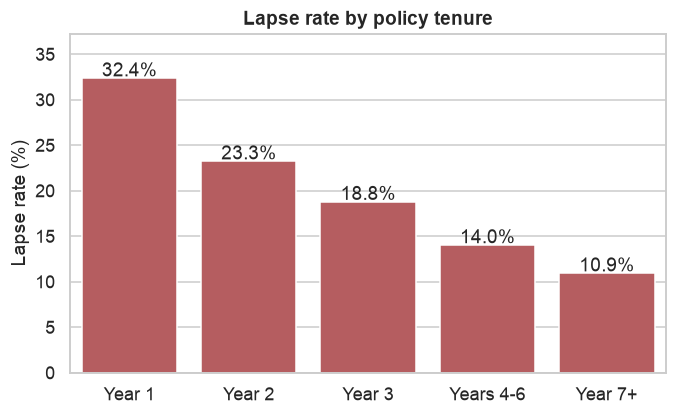

In [11]:
df["tenure_year"] = pd.cut(
    df["policy_tenure_months"], bins=[0, 12, 24, 36, 72, 400],
    labels=["Year 1", "Year 2", "Year 3", "Years 4-6", "Year 7+"]
)
by_tenure = df.groupby("tenure_year", observed=True)["lapsed"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=by_tenure.index, y=by_tenure.values, ax=ax, color="#C44E52")
for i, v in enumerate(by_tenure.values):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center")
ax.set_ylabel("Lapse rate (%)")
ax.set_xlabel("")
ax.set_title("Lapse rate by policy tenure")
ax.set_ylim(0, by_tenure.max() * 1.15)
save(fig, "06_lapse_by_tenure")
plt.show()

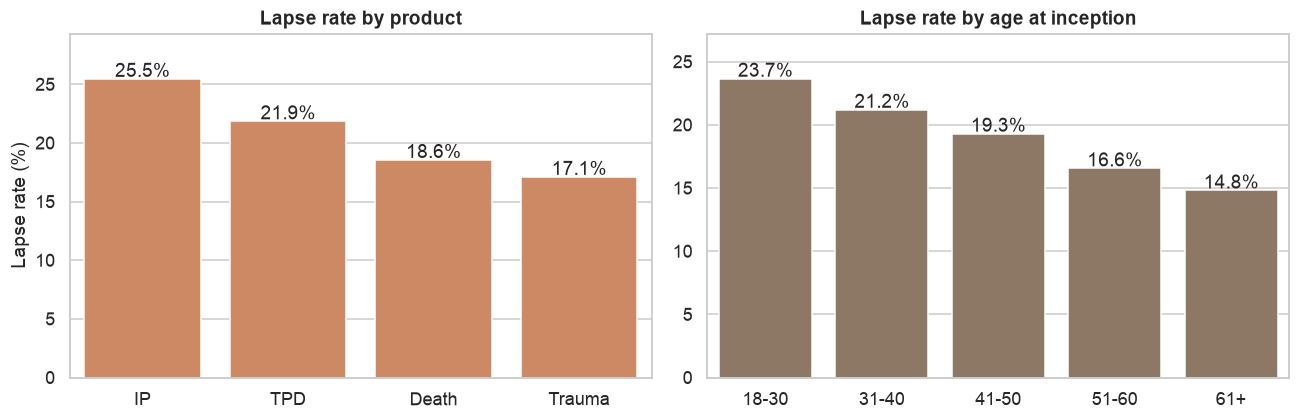

In [12]:
df["age_band"] = pd.cut(df["age_at_inception"], bins=[17, 30, 40, 50, 60, 80],
                        labels=["18-30", "31-40", "41-50", "51-60", "61+"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_product = df.groupby("product_type")["lapsed"].mean().sort_values(ascending=False) * 100
sns.barplot(x=by_product.index, y=by_product.values, ax=axes[0], color="#DD8452")
axes[0].set_title("Lapse rate by product")
axes[0].set_ylabel("Lapse rate (%)")

by_age = df.groupby("age_band", observed=True)["lapsed"].mean() * 100
sns.barplot(x=by_age.index, y=by_age.values, ax=axes[1], color="#937860")
axes[1].set_title("Lapse rate by age at inception")
axes[1].set_ylabel("")

for ax, s in zip(axes, [by_product, by_age]):
    for i, v in enumerate(s.values):
        ax.text(i, v + 0.15, f"{v:.1f}%", ha="center")
    ax.set_ylim(0, s.max() * 1.15)
    ax.set_xlabel("")
fig.tight_layout()
save(fig, "07_lapse_by_product_age")
plt.show()

**Finding:** about 8% of policies lapse, so the classes are heavily imbalanced. Lapse risk is highest in the first year and drops sharply with tenure. Income protection lapses the most, and younger policyholders lapse more than older ones.

**Decision:**
- Accuracy is useless here. Evaluate with **AUC-ROC** and **precision-recall AUC**.
- Handle imbalance with **class weighting** and **threshold tuning**.
- Tenure will likely be the strongest feature. Keep it as a continuous number rather than bands, so the model can learn the decay curve itself.

## 5. Feature relationships

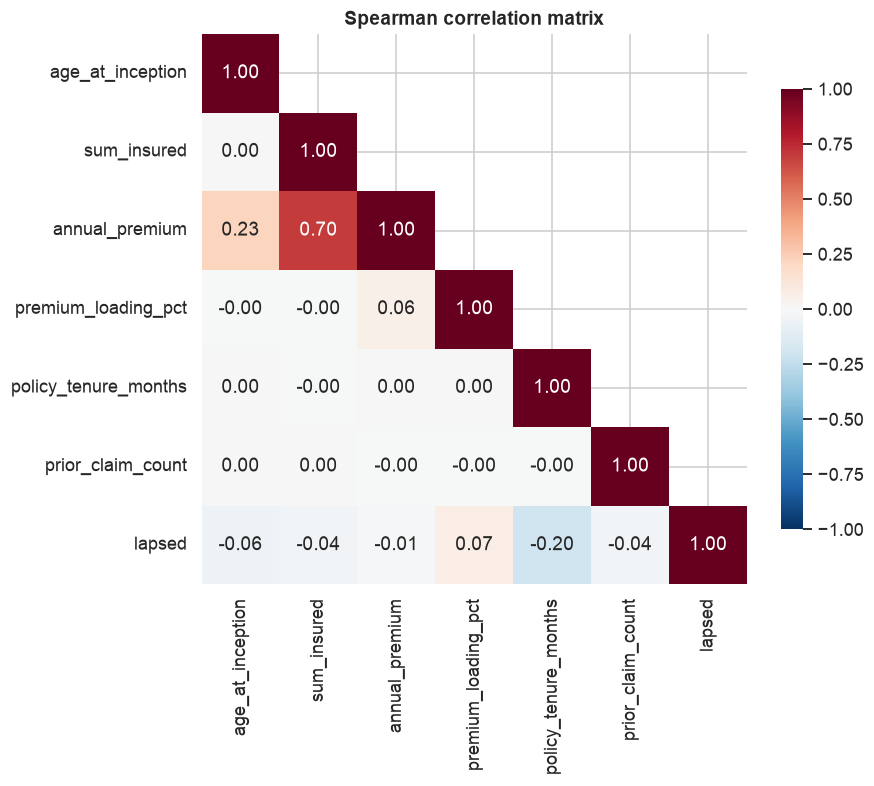

In [13]:
corr_cols = ["age_at_inception", "sum_insured", "annual_premium",
             "premium_loading_pct", "policy_tenure_months", "prior_claim_count", "lapsed"]
corr = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Spearman correlation matrix")
save(fig, "08_correlation_matrix")
plt.show()

*Spearman rather than Pearson because the money columns are skewed. Spearman measures rank relationships, so outliers don't distort it.*

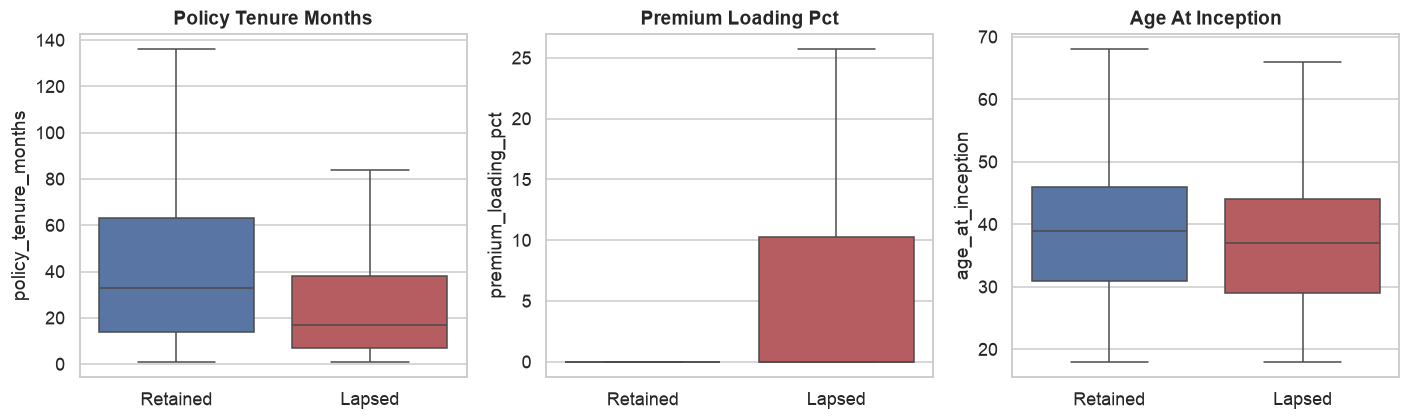

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_cols = ["policy_tenure_months", "premium_loading_pct", "age_at_inception"]
for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=df, x="lapsed", y=col, ax=ax, hue="lapsed",
                palette=["#4C72B0", "#C44E52"], legend=False, showfliers=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Retained", "Lapsed"])
    ax.set_xlabel("")
    ax.set_title(col.replace("_", " ").title())
fig.tight_layout()
save(fig, "09_boxplots_by_target")
plt.show()

In [15]:
# Premium and sum insured are strongly linked. Check before using both in a linear model.
r = df[["sum_insured", "annual_premium"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation, sum_insured vs annual_premium: {r:.2f}")

Spearman correlation, sum_insured vs annual_premium: 0.70


**Finding:** lapsed policies have noticeably shorter tenure, higher premium loadings, and slightly younger policyholders. `sum_insured` and `annual_premium` are strongly correlated with each other.

**Decision:** the correlated pair causes unstable coefficients in logistic regression (multicollinearity). Engineer a `premium_to_sum_insured` ratio feature, which captures price relative to cover and may matter more than either raw value.

## 6. Summary and modelling plan

| Finding | Modelling decision |
|---|---|
| ~8% lapse rate (severe imbalance) | AUC-ROC + PR-AUC, class weights, threshold tuning |
| Lapse risk decays with tenure | Tenure as a continuous feature |
| Money columns are log-normal | Log-transform for logistic regression only |
| Low, random missingness | Median imputation; `Unknown` smoker category |
| Premium and sum insured correlated | Add premium-to-cover ratio feature |
| Product and age matter | One-hot encode product; keep age continuous |

**Next notebook:** `02_baseline_model.ipynb`, logistic regression baseline with a 70/15/15 split.

In [16]:
# Drop helper columns created for plotting only
df = df.drop(columns=["tenure_year", "age_band"])
print("EDA complete. Figures saved to:", FIG_DIR.resolve())

EDA complete. Figures saved to: /Users/kushalumesh/Documents/projects/lapsation-prediction/figures
